#### Libraries

In [1]:
#pip install pandas numpy matplotlib Pillow grad-cam scikit-learn
#pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
    #Alternatively: https://pytorch.org/get-started/locally/
import os

from collections import defaultdict

from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split



# Preprocessing

#### Define Transformations

In [2]:
from torchvision import transforms

# Standard dimensions for ResNet50 and MobileNetV2
IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0)),  # More aggressive crop
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),                            # Add vertical flips
    transforms.RandomRotation(30),                              # Add rotation
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),  # Stronger jitter
    transforms.RandomGrayscale(p=0.1),                         # Occasionally grayscale
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Validation transforms should be clean (no random flips/crops)
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#### Data Load

In [45]:
data_dir = 'I:/Capstone/Project_Contents/Plant_Pictures/Plant_Data/'

"""
Healthy           → 0
Light_Deficient   → 1
Light_Saturation  → 2
Water_Deficient   → 3
"""
full_dataset = ImageFolder(root=data_dir)

"""
full_dataset.class_to_idx  {'Healthy': 0, 'Light_Saturation': 1, ...}
full_dataset.classes       ['Healthy', 'Light_Saturation', 'Water_Deficient', 'Water_Saturation']
full_dataset.imgs          list of (path, label) tuples for every image
full_dataset.targets       just the labels from imgs, e.g. [0, 0, 0, 1, 1, 2, ...]
full_dataset.root          the root directory you passed in
"""

#Swap Key-Value pairings
#{'Healthy': 0, 'Light_Saturation': 1, 'Water_Deficient': 2, 'Water_Saturation': 3}
#{0: 'Healthy', 1: 'Light_Saturation', 2: 'Water_Deficient', 3: 'Water_Saturation'}
idx_to_class = {}
for name, number in full_dataset.class_to_idx.items():
    idx_to_class[number] = name

In [4]:
print(idx_to_class)

{0: 'Healthy', 1: 'Light_Deficient', 2: 'Light_Saturation', 3: 'Water_Deficient'}


#### YOLO

In [5]:
# #YOLO
# pip install ultralytics

In [6]:
# from ultralytics import YOLO
# from PIL import Image
# import torch
# import os

# # Load a pretrained YOLOv8 model
# yolo_model = YOLO('yolov8n.pt')

# def detect_and_crop_plant(image_path, output_path, padding=20):
#     """
#     Runs YOLO on an image, finds the most prominent object (the plant),
#     crops it out with some padding, and saves it to output_path.

#     Args:
#         image_path  : path to the original image
#         output_path : path to save the cropped image
#         padding     : extra pixels around the bounding box to avoid cutting edges
    
#     Returns:
#         True if a detection was found and saved
#         False if nothing was detected — original image is saved as fallback
#     """
#     image = Image.open(image_path).convert('RGB')
#     results = yolo_model(image, verbose=False)

#     # Get all bounding boxes from the first result
#     boxes = results[0].boxes

#     if boxes is not None and len(boxes) > 0:
#         # Take the bounding box with the highest confidence score
#         best_box = boxes[boxes.conf.argmax()]
#         x1, y1, x2, y2 = best_box.xyxy[0].cpu().numpy().astype(int)

#         # Add padding but clamp to image boundaries
#         width, height = image.size
#         x1 = max(0, x1 - padding)
#         y1 = max(0, y1 - padding)
#         x2 = min(width,  x2 + padding)
#         y2 = min(height, y2 + padding)

#         # Crop and save
#         cropped = image.crop((x1, y1, x2, y2))
#         cropped.save(output_path)
#         return True
#     else:
#         # No detection — save original as fallback so training still has an image
#         image.save(output_path)
#         return False

In [7]:
# import shutil
# from pathlib import Path

# # Original data directory
# data_dir    = 'I:/Capstone/Project_Contents/Plant_Pictures/Plant_Data/'

# # New directory where cropped images will be saved
# cropped_dir = 'I:/Capstone/Project_Contents/Plant_Pictures/Plant_Data_Cropped/'

# detected    = 0
# not_detected = 0

# print("Processing images with YOLO...")
# print("This may take a while depending on dataset size.\n")

# for class_folder in os.listdir(data_dir):
#     class_input_path  = os.path.join(data_dir, class_folder)
#     class_output_path = os.path.join(cropped_dir, class_folder)

#     # Skip if not a directory
#     if not os.path.isdir(class_input_path):
#         continue

#     # Create matching class folder in output directory
#     os.makedirs(class_output_path, exist_ok=True)

#     for filename in os.listdir(class_input_path):
#         if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
#             continue

#         input_path  = os.path.join(class_input_path, filename)
#         output_path = os.path.join(class_output_path, filename)

#         # Skip if already processed
#         if os.path.exists(output_path):
#             continue

#         success = detect_and_crop_plant(input_path, output_path)

#         if success:
#             detected += 1
#         else:
#             not_detected += 1

#         # Progress update every 50 images
#         total = detected + not_detected
#         if total % 50 == 0:
#             print(f"Processed {total} images — Detected: {detected} | Fallback: {not_detected}")

# print(f"\nDone!")
# print(f"Successfully cropped : {detected} images")
# print(f"Fallback (no detection): {not_detected} images")
# print(f"Cropped dataset saved to: {cropped_dir}")

In [8]:
# # From this point forward, all loading uses the cropped dataset
# data_dir = 'I:/Capstone/Project_Contents/Plant_Pictures/Plant_Data_Cropped/'

# # Reload full_dataset from the cropped directory
# full_dataset = ImageFolder(root=data_dir)
# idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}

# print(f"Loaded cropped dataset: {len(full_dataset)} images")
# print(f"Classes: {full_dataset.classes}")

#### OpenCV (GrabCut)


GrabCut Function

In [ ]:
import cv2
import numpy as np
from PIL import Image
import os

def grabcut_crop(image_path, output_path, padding=20):
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        Image.open(image_path).save(output_path)
        return False

    # Store original dimensions before resizing
    original_h, original_w = image_bgr.shape[:2]

    # Resize for GrabCut calculation only
    max_size = 500
    if max(original_h, original_w) > max_size:
        scale     = max_size / max(original_h, original_w)
        image_bgr = cv2.resize(image_bgr, (int(original_w * scale), int(original_h * scale)))
    else:
        scale = 1.0  # No resize needed, scale factor is 1

    height, width = image_bgr.shape[:2]

    margin_x = int(width  * 0.1)
    margin_y = int(height * 0.1)
    rect = (margin_x, margin_y, width - margin_x * 2, height - margin_y * 2)

    mask     = np.zeros((height, width), np.uint8)
    bg_model = np.zeros((1, 65), np.float64)
    fg_model = np.zeros((1, 65), np.float64)

    cv2.grabCut(image_bgr, mask, rect, bg_model, fg_model, 5, cv2.GC_INIT_WITH_RECT)

    binary_mask = np.where(
        (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0
    ).astype('uint8')

    coords = cv2.findNonZero(binary_mask)
    if coords is None:
        Image.open(image_path).save(output_path)
        return False

    x, y, w, h = cv2.boundingRect(coords)

    # Scale coordinates back up to original image dimensions
    x1 = max(0, int((x - padding)         / scale))
    y1 = max(0, int((y - padding)         / scale))
    x2 = min(original_w, int((x + w + padding) / scale))
    y2 = min(original_h, int((y + h + padding) / scale))

    # Crop from the original full resolution image
    image_pil = Image.open(image_path).convert('RGB')
    cropped   = image_pil.crop((x1, y1, x2, y2))
    cropped.save(output_path)
    return True

Small Test

In [10]:
# # Test on a single image first
# test_input  = 'I:/Capstone/Project_Contents/Plant_Pictures/Plant_Data/Healthy/Arrowhead_A2_Healthy_Kitchen_Above_Close.jpg'
# test_output = 'I:/Capstone/Project_Contents/Plant_Pictures/test_crop.jpg'

# print("Starting test...")
# result = grabcut_crop(test_input, test_output)
# print(f"Done — Success: {result}")

Preprocess Dataset w/ GrabCut

In [11]:
# data_dir    = 'I:/Capstone/Project_Contents/Plant_Pictures/Plant_Data/'
# cropped_dir = 'I:/Capstone/Project_Contents/Plant_Pictures/Plant_Data_GrabCut/'

# successful = 0
# fallback   = 0

# print("Processing images with GrabCut...")
# print("This may take a while.\n")

# for class_folder in os.listdir(data_dir):
#     class_input_path  = os.path.join(data_dir, class_folder)
#     class_output_path = os.path.join(cropped_dir, class_folder)

#     if not os.path.isdir(class_input_path):
#         continue

#     os.makedirs(class_output_path, exist_ok=True)

#     for filename in os.listdir(class_input_path):
#         if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
#             continue

#         input_path  = os.path.join(class_input_path, filename)
#         output_path = os.path.join(class_output_path, filename)

#         if os.path.exists(output_path):
#             continue

#         success = grabcut_crop(input_path, output_path)

#         if success:
#             successful += 1
#         else:
#             fallback += 1

#         total = successful + fallback
#         if total % 50 == 0:
#             print(f"Processed {total} images — Successful: {successful} | Fallback: {fallback}")

# print(f"\nDone!")
# print(f"Successfully cropped : {successful} images")
# print(f"Fallback             : {fallback} images")
# print(f"Saved to             : {cropped_dir}")

View Samples

In [12]:
# import matplotlib.pyplot as plt
# import random

# def show_grabcut_samples(original_dir, cropped_dir, class_name, n=6):
#     """
#     Shows a side by side comparison of original vs GrabCut cropped images
#     so you can visually verify the results before training.
#     """
#     original_class = os.path.join(original_dir, class_name)
#     cropped_class  = os.path.join(cropped_dir,  class_name)

#     files   = [f for f in os.listdir(original_class) if f.endswith('.jpg')]
#     samples = random.sample(files, min(n, len(files)))

#     fig, axes = plt.subplots(2, n, figsize=(20, 8))
#     fig.suptitle(f"GrabCut Results — {class_name}", fontsize=14)

#     axes[0, 0].set_ylabel('Original', fontsize=12)
#     axes[1, 0].set_ylabel('GrabCut', fontsize=12)

#     for i, filename in enumerate(samples):
#         original_path = os.path.join(original_class, filename)
#         cropped_path  = os.path.join(cropped_class,  filename)

#         original_img  = Image.open(original_path).convert('RGB')
#         cropped_img   = Image.open(cropped_path).convert('RGB')

#         axes[0, i].imshow(original_img)
#         axes[0, i].set_title(filename[:20], fontsize=7)
#         axes[0, i].axis('off')

#         axes[1, i].imshow(cropped_img)
#         axes[1, i].axis('off')

#     plt.tight_layout()

# # Check each class
# for class_name in ['Healthy', 'Light_Saturation', 'Water_Deficient']:
#     show_grabcut_samples(data_dir, cropped_dir, class_name, n=6)

Set the dataset to use the new Cropped images

In [ ]:
# data_dir     = 'I:/Capstone/Project_Contents/Plant_Pictures/Plant_Data_GrabCut/'
# full_dataset = ImageFolder(root=data_dir)
# idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}

# print(f"Loaded GrabCut dataset : {len(full_dataset)} images")
# print(f"Classes                : {full_dataset.classes}")

Loaded GrabCut dataset : 1066 images
Classes                : ['Healthy', 'Light_Deficient', 'Light_Saturation', 'Water_Deficient']


#### Split Between Standard and Extra

In [14]:
# All images go into the standard pool — no Extra separation
standard_indices = []

for idx, (path, label) in enumerate(full_dataset.imgs):
    standard_indices.append(idx)

standard_data = Subset(full_dataset, standard_indices)

print(f"Total images : {len(standard_data)}")

Total images : 1066


#### Verification - Split by Room

In [15]:
def make_class_counter():
    return defaultdict(int)

species_class_counts = defaultdict(make_class_counter)

for i in standard_data.indices:
    path, label = full_dataset.imgs[i]
    filename    = os.path.basename(path)
    species     = filename.split('_')[0]
    classname   = idx_to_class[label]
    species_class_counts[species][classname] += 1

print("---Image Spread of Standard Dataset---")

for species in sorted(species_class_counts):
    print(f"\n  {species}:")
    for classname, count in sorted(species_class_counts[species].items()):
        print(f"    {classname}: {count} images")

---Image Spread of Standard Dataset---

  Arrowhead:
    Healthy: 117 images
    Light_Deficient: 52 images
    Light_Saturation: 52 images
    Water_Deficient: 52 images

  Fittonia:
    Healthy: 117 images
    Light_Deficient: 52 images
    Light_Saturation: 52 images
    Water_Deficient: 52 images

  Pothos:
    Healthy: 117 images
    Light_Deficient: 26 images
    Light_Saturation: 52 images
    Water_Deficient: 52 images

  Waffle:
    Healthy: 117 images
    Light_Deficient: 52 images
    Light_Saturation: 52 images
    Water_Deficient: 52 images


#### Sample Images

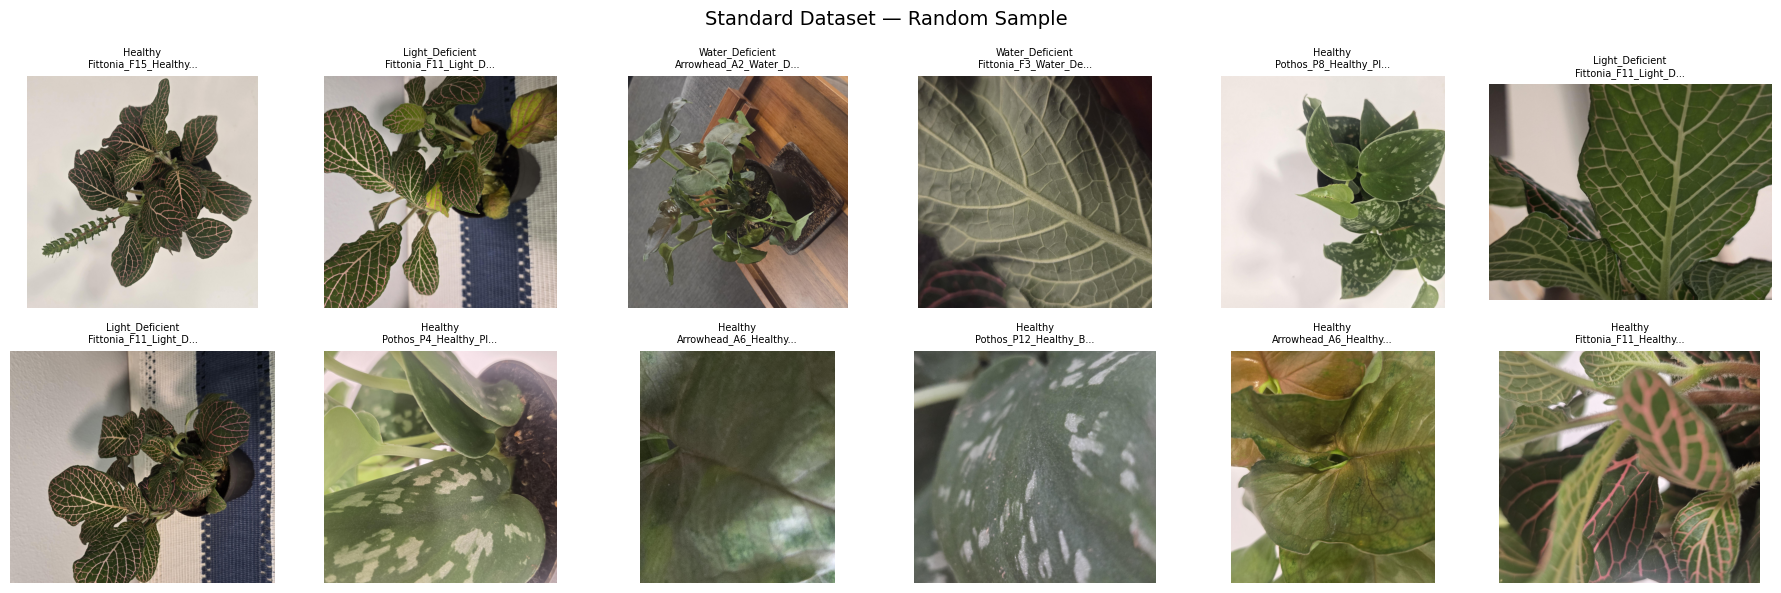

In [16]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_sample_grid(subset, full_dataset, title, n=12):
    fig, axes = plt.subplots(2, n//2, figsize=(18, 6))
    fig.suptitle(title, fontsize=14)
    
    sample_indices = random.sample(list(subset.indices), n)
    
    for ax, i in zip(axes.flat, sample_indices):
        path, label = full_dataset.imgs[i]
        img = Image.open(path).convert('RGB')
        ax.imshow(img)
        ax.set_title(f"{idx_to_class[label]}\n{os.path.basename(path)[:20]}...", fontsize=7)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

show_sample_grid(standard_data,   full_dataset, "Standard Dataset — Random Sample")

#### Splitting into Train/Val

In [17]:
BACKGROUND_TYPES = ['_Plain_', '_Bedroom_', '_Kitchen_', '_LivingRoom_']

def get_background(filename):
    for bg in BACKGROUND_TYPES:
        if bg in filename:
            return bg.strip('_')
    return 'Unknown'

stratify_keys = []
for i in standard_data.indices:
    path, label = full_dataset.imgs[i]
    filename    = os.path.basename(path)
    classname   = idx_to_class[label]
    background  = get_background(filename)
    stratify_keys.append(f"{classname}_{background}")

#80/20 split
train_indices, val_indices = train_test_split(
    standard_indices,
    test_size=0.20,
    stratify=stratify_keys,
    random_state=42
)

train_data = Subset(full_dataset, train_indices)
val_data   = Subset(full_dataset, val_indices)

print(f"Train images : {len(train_data)}")
print(f"Val images   : {len(val_data)}")

Train images : 852
Val images   : 214


#### Apply Transformations

In [18]:
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset       = subset
        self.transform    = transform
        self.classes      = subset.dataset.classes
        self.class_to_idx = subset.dataset.class_to_idx

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        path, label = self.subset.dataset.imgs[self.subset.indices[idx]]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

train_data_final = TransformSubset(train_data, train_transforms)
val_data_final   = TransformSubset(val_data,   val_transforms)

#### Create Training Batches

In [19]:
train_loader = DataLoader(train_data_final, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_data_final,   batch_size=32, shuffle=False, num_workers=0)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train batches : 27
Val batches   : 7


#### Device setup for Models

In [20]:
#pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124 --force-reinstall

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt

NUM_CLASSES = 4
EPOCHS      = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected — training will run on CPU")

#Compares the model's predicted probabilities across all 4 classes against the true label and produces a single number representing how wrong it was
criterion = nn.CrossEntropyLoss()

Using device: cuda
GPU name: NVIDIA GeForce RTX 3080


# ResNet50

#### Build ResNet50

#### Fully Frozen

In [21]:
# resnet50 = models.resnet50(weights='IMAGENET1K_V2')

# ResnetFreezeAmount = "Full Freeze"

# # Freeze all layers
# for param in resnet50.parameters():
#     param.requires_grad = False

# # Replace final layer to match the 4 classes
# in_features      = resnet50.fc.in_features
# resnet50.fc      = nn.Linear(in_features, NUM_CLASSES)
# resnet50         = resnet50.to(device)

# # Sanity check
# trainable = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
# total     = sum(p.numel() for p in resnet50.parameters())
# print(f"ResNet50 — trainable params: {trainable:,} / {total:,}")

#### Partially Frozen (last layer(4) unfrozen)

In [22]:
resnet50 = models.resnet50(weights='IMAGENET1K_V2')

ResnetFreezeAmount = "Partial Freeze"

# Freeze all layers
for param in resnet50.parameters():
    param.requires_grad = False

# Unfreeze the last residual block
for param in resnet50.layer4.parameters():
    param.requires_grad = True

# Replace final layer to match the 4 classes
in_features  = resnet50.fc.in_features                  # Measure the size of the final layer that is unfrozen
resnet50.fc  = nn.Linear(in_features, NUM_CLASSES)      # Create a final layer that match my 4 classes
resnet50     = resnet50.to(device)                      # Load the model into GPU memory

# Sanity check
trainable = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet50.parameters())
print(f"ResNet50 — trainable params: {trainable:,} / {total:,}")

ResNet50 — trainable params: 14,972,932 / 23,516,228


#### ResNet50 optimiser

In [23]:
 #Configure how the model updates weights during training
trainable_params = [p for p in resnet50.parameters() if p.requires_grad]

resnet50_optimiser = optim.Adam(trainable_params, lr=0.001)

#### Train ResNet50

In [24]:
resnet50_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(ResnetFreezeAmount)

for epoch in range(EPOCHS):

    # ── Training phase ──────────────────────────────────────────────
    resnet50.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        resnet50_optimiser.zero_grad()      # Pytorch will accumulate the loss during training by default, this clears it
        outputs = resnet50(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        resnet50_optimiser.step()

        train_loss    += loss.item() * images.size(0)
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    # ── Validation phase ────────────────────────────────────────────
    resnet50.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = resnet50(images)
            loss     = criterion(outputs, labels)

            val_loss    += loss.item() * images.size(0)
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    # ── Epoch metrics ────────────────────────────────────────────────
    epoch_train_loss = train_loss / train_total
    epoch_train_acc  = train_correct / train_total
    epoch_val_loss   = val_loss / val_total
    epoch_val_acc    = val_correct / val_total

    resnet50_history['train_loss'].append(epoch_train_loss)
    resnet50_history['train_acc'].append(epoch_train_acc)
    resnet50_history['val_loss'].append(epoch_val_loss)
    resnet50_history['val_acc'].append(epoch_val_acc)

    print(
        f"[ResNet50] Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {epoch_train_loss:.4f}  Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}  Acc: {epoch_val_acc:.4f}"
    )

Partial Freeze
[ResNet50] Epoch 01/10 | Train Loss: 1.2405  Acc: 0.4495 | Val Loss: 1.3620  Acc: 0.5093
[ResNet50] Epoch 02/10 | Train Loss: 0.9995  Acc: 0.6197 | Val Loss: 1.2751  Acc: 0.6075
[ResNet50] Epoch 03/10 | Train Loss: 0.7904  Acc: 0.6948 | Val Loss: 0.7521  Acc: 0.6963
[ResNet50] Epoch 04/10 | Train Loss: 0.6872  Acc: 0.7230 | Val Loss: 0.5939  Acc: 0.7430
[ResNet50] Epoch 05/10 | Train Loss: 0.5829  Acc: 0.7746 | Val Loss: 0.5758  Acc: 0.7617
[ResNet50] Epoch 06/10 | Train Loss: 0.4756  Acc: 0.8169 | Val Loss: 0.4933  Acc: 0.8364
[ResNet50] Epoch 07/10 | Train Loss: 0.4821  Acc: 0.8263 | Val Loss: 0.4965  Acc: 0.7804
[ResNet50] Epoch 08/10 | Train Loss: 0.4496  Acc: 0.8263 | Val Loss: 0.6290  Acc: 0.8131
[ResNet50] Epoch 09/10 | Train Loss: 0.3852  Acc: 0.8721 | Val Loss: 0.4625  Acc: 0.8505
[ResNet50] Epoch 10/10 | Train Loss: 0.3529  Acc: 0.8744 | Val Loss: 0.5916  Acc: 0.7850


#### Plot ResNet50 history

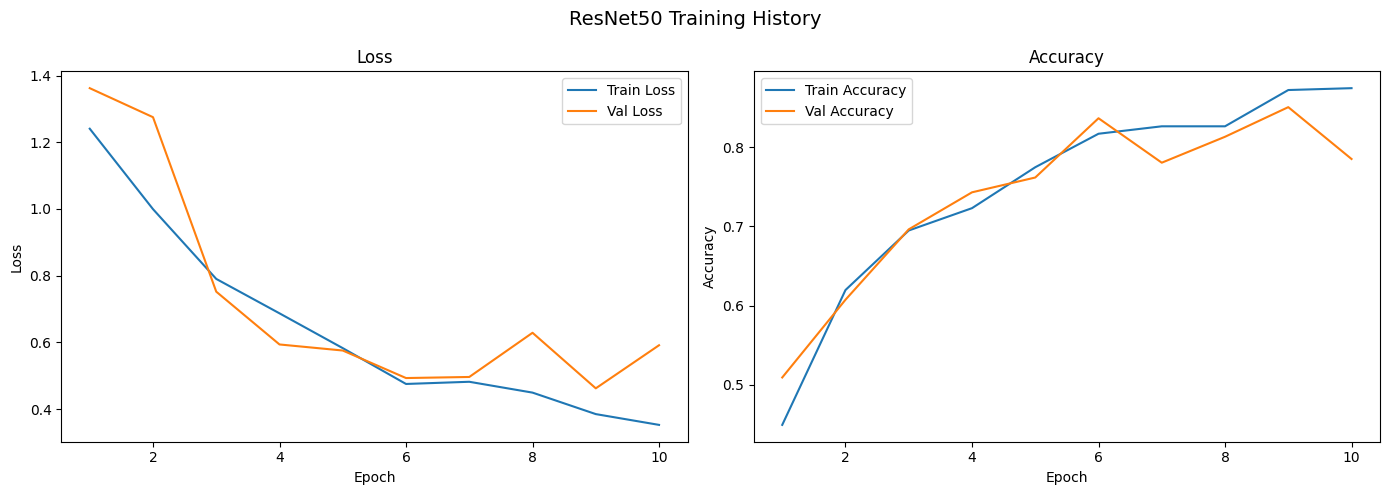

In [25]:
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ResNet50 Training History", fontsize=14)

ax1.plot(epochs, resnet50_history['train_loss'], label='Train Loss')
ax1.plot(epochs, resnet50_history['val_loss'],   label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, resnet50_history['train_acc'], label='Train Accuracy')
ax2.plot(epochs, resnet50_history['val_acc'],   label='Val Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

#### Grad-Cam

ResNet50 GradCAM — Validation Set


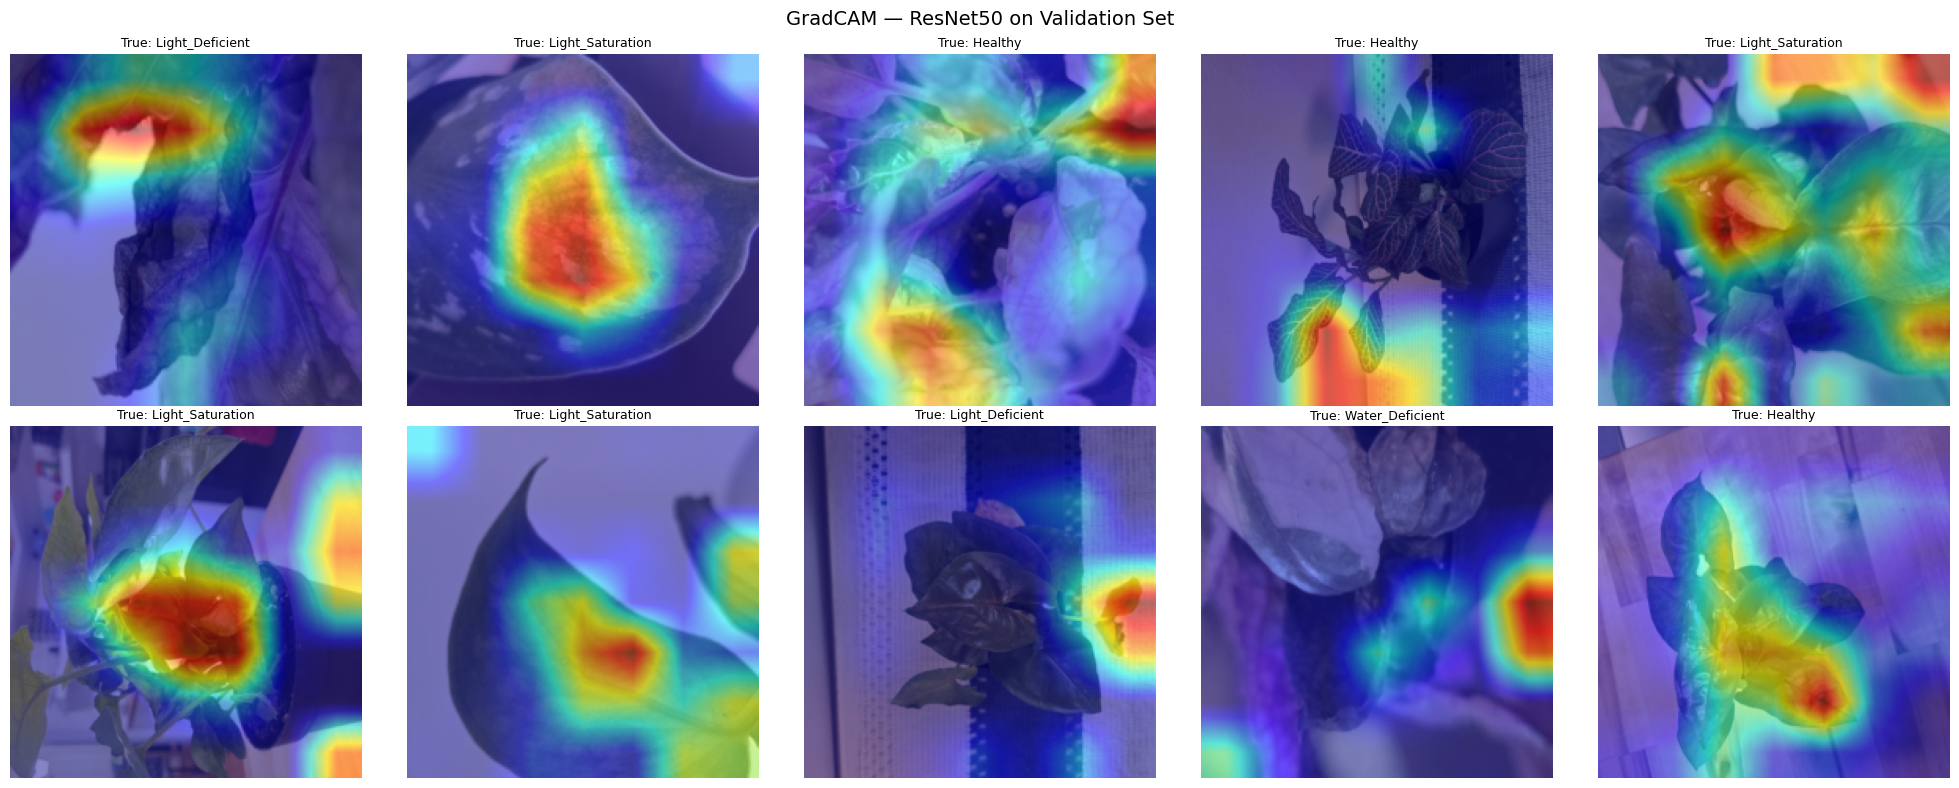

In [26]:
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def run_gradcam(model, target_layer, loader, dataset_name, model_name, num_images=8):
    model.eval()

    # Temporarily unfreeze the target layer so GradCAM can capture gradients
    for param in target_layer.parameters():
        param.requires_grad = True

    cam = GradCAM(model=model, target_layers=[target_layer])

    images, labels = next(iter(loader))
    images = images[:num_images]
    labels = labels[:num_images]

    fig, axes = plt.subplots(2, num_images // 2, figsize=(20, 8))
    fig.suptitle(f"GradCAM — {model_name} on {dataset_name}", fontsize=14)

    for i in range(num_images):
        image_tensor = images[i].unsqueeze(0).to(device)
        label        = labels[i].item()
        target       = [ClassifierOutputTarget(label)]

        grayscale_cam = cam(input_tensor=image_tensor, targets=target)
        grayscale_cam = grayscale_cam[0]

        # Undo normalisation so the image is displayable
        raw_image = images[i].numpy().transpose(1, 2, 0)
        raw_image = raw_image * np.array([0.229, 0.224, 0.225])
        raw_image = raw_image + np.array([0.485, 0.456, 0.406])
        raw_image = np.clip(raw_image, 0, 1).astype(np.float32)

        cam_image = show_cam_on_image(raw_image, grayscale_cam, use_rgb=True)

        ax = axes.flat[i]
        ax.imshow(cam_image)
        ax.set_title(f"True: {idx_to_class[label]}", fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    # Re-freeze the target layer after GradCAM is done
    for param in target_layer.parameters():
        param.requires_grad = False


# ResNet50's best layer for GradCAM is the last conv layer before the classifier
resnet50_target_layer = resnet50.layer4[-1]

print("ResNet50 GradCAM — Validation Set")
run_gradcam(
    model        = resnet50,
    target_layer = resnet50_target_layer,
    loader       = val_loader,
    dataset_name = "Validation Set",
    model_name   = "ResNet50",
    num_images   = 10
)

# print("ResNet50 GradCAM — Inconsistency Test Set (_Extra_)")
# run_gradcam(
#     model        = resnet50,
#     target_layer = resnet50_target_layer,
#     loader       = extra_loader,
#     dataset_name = "Inconsistency Test Set",
#     model_name   = "ResNet50",
#     num_images   = 10
# )

# MobileNetV2

#### Build MobileNetV2

#### Full Freeze (except last layer)

In [27]:
# mobilenetv2 = models.mobilenet_v2(weights='IMAGENET1K_V2')

# MobileNetFreezeAmount = "Full Freeze"

# # Freeze all layers
# for param in mobilenetv2.parameters():
#     param.requires_grad = False

# # Replace final layer to match the 4 classes
# in_features                  = mobilenetv2.classifier[1].in_features
# mobilenetv2.classifier[1]    = nn.Linear(in_features, NUM_CLASSES)
# mobilenetv2                  = mobilenetv2.to(device)

# # Sanity check
# trainable = sum(p.numel() for p in mobilenetv2.parameters() if p.requires_grad)
# total     = sum(p.numel() for p in mobilenetv2.parameters())
# print(f"MobileNetV2 — trainable params: {trainable:,} / {total:,}")

#### Partial Freeze (Last 3 layers unfrozen)

In [28]:
mobilenetv2 = models.mobilenet_v2(weights='IMAGENET1K_V2')

MobileNetFreezeAmount = "Partial Freeze"

# Freeze all layers
for param in mobilenetv2.parameters():
    param.requires_grad = False

# Unfreeze the last 3 feature layers
for param in mobilenetv2.features[-3:].parameters():
    param.requires_grad = True

# Replace final layer to match the 4 classes
in_features                = mobilenetv2.classifier[1].in_features
mobilenetv2.classifier[1]  = nn.Linear(in_features, NUM_CLASSES)
mobilenetv2                = mobilenetv2.to(device)

# Sanity check
trainable = sum(p.numel() for p in mobilenetv2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in mobilenetv2.parameters())
print(f"MobileNetV2 — trainable params: {trainable:,} / {total:,}")

MobileNetV2 — trainable params: 1,211,204 / 2,228,996


#### MobileNetV2 optimiser

In [29]:
#Configure how the model updates weights during training
trainable_params = [p for p in mobilenetv2.parameters() if p.requires_grad]

mobilenetv2_optimiser = optim.Adam(trainable_params, lr=0.001)

#### Train MobileNetV2

In [30]:
mobilenetv2_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(MobileNetFreezeAmount)

for epoch in range(EPOCHS):

    # ── Training phase ──────────────────────────────────────────────
    mobilenetv2.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        mobilenetv2_optimiser.zero_grad()
        outputs = mobilenetv2(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        mobilenetv2_optimiser.step()

        train_loss    += loss.item() * images.size(0)
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    # ── Validation phase ────────────────────────────────────────────
    mobilenetv2.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = mobilenetv2(images)
            loss     = criterion(outputs, labels)

            val_loss    += loss.item() * images.size(0)
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    # ── Epoch metrics ────────────────────────────────────────────────
    epoch_train_loss = train_loss / train_total
    epoch_train_acc  = train_correct / train_total
    epoch_val_loss   = val_loss / val_total
    epoch_val_acc    = val_correct / val_total

    mobilenetv2_history['train_loss'].append(epoch_train_loss)
    mobilenetv2_history['train_acc'].append(epoch_train_acc)
    mobilenetv2_history['val_loss'].append(epoch_val_loss)
    mobilenetv2_history['val_acc'].append(epoch_val_acc)

    print(
        f"[MobileNetV2] Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {epoch_train_loss:.4f}  Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}  Acc: {epoch_val_acc:.4f}"
    )

Partial Freeze
[MobileNetV2] Epoch 01/10 | Train Loss: 1.2632  Acc: 0.4636 | Val Loss: 1.1331  Acc: 0.5374
[MobileNetV2] Epoch 02/10 | Train Loss: 1.0431  Acc: 0.5575 | Val Loss: 0.9031  Acc: 0.6355
[MobileNetV2] Epoch 03/10 | Train Loss: 0.8942  Acc: 0.6326 | Val Loss: 0.9328  Acc: 0.6402
[MobileNetV2] Epoch 04/10 | Train Loss: 0.8151  Acc: 0.6714 | Val Loss: 1.6203  Acc: 0.4907
[MobileNetV2] Epoch 05/10 | Train Loss: 0.7363  Acc: 0.6984 | Val Loss: 0.7921  Acc: 0.6776
[MobileNetV2] Epoch 06/10 | Train Loss: 0.6919  Acc: 0.7171 | Val Loss: 0.8292  Acc: 0.6916
[MobileNetV2] Epoch 07/10 | Train Loss: 0.6713  Acc: 0.7312 | Val Loss: 0.8413  Acc: 0.6589
[MobileNetV2] Epoch 08/10 | Train Loss: 0.6530  Acc: 0.7394 | Val Loss: 0.8700  Acc: 0.6215
[MobileNetV2] Epoch 09/10 | Train Loss: 0.5787  Acc: 0.7793 | Val Loss: 0.9972  Acc: 0.5935
[MobileNetV2] Epoch 10/10 | Train Loss: 0.5723  Acc: 0.7770 | Val Loss: 0.8629  Acc: 0.6729


#### Plot MobileNetV2 history

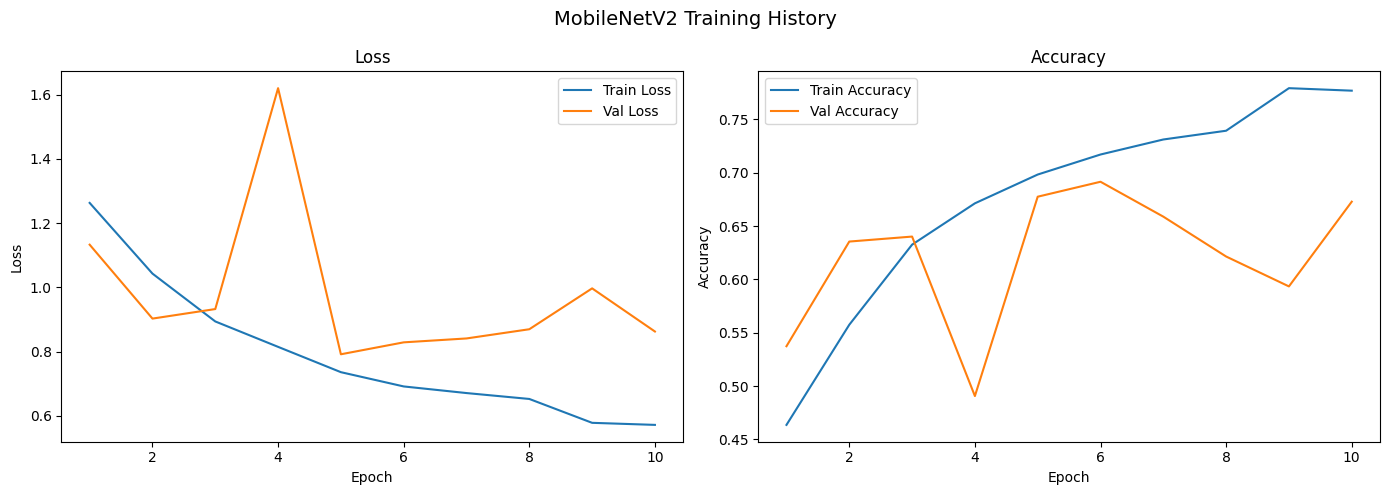

In [31]:
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MobileNetV2 Training History", fontsize=14)

ax1.plot(epochs, mobilenetv2_history['train_loss'], label='Train Loss')
ax1.plot(epochs, mobilenetv2_history['val_loss'],   label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, mobilenetv2_history['train_acc'], label='Train Accuracy')
ax2.plot(epochs, mobilenetv2_history['val_acc'],   label='Val Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

#### Grad-Cam

MobileNetV2 GradCAM — Validation Set


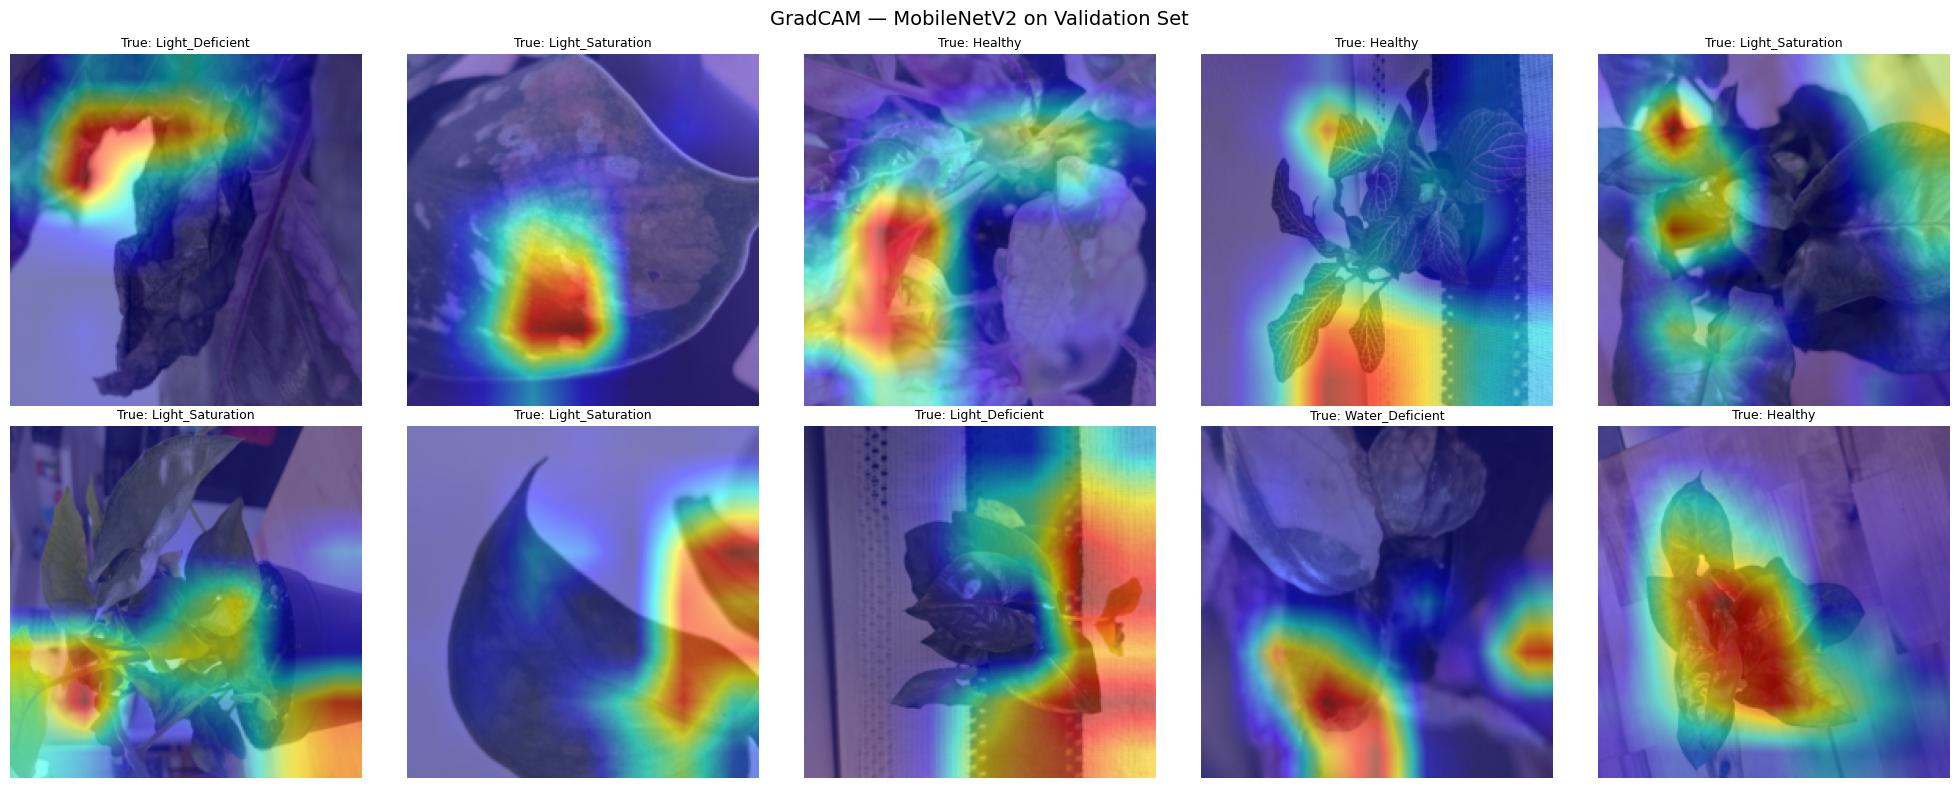

In [32]:
# MobileNetV2's best layer for GradCAM is the last conv layer in the features block
mobilenetv2_target_layer = mobilenetv2.features[-1]

print("MobileNetV2 GradCAM — Validation Set")
run_gradcam(
    model        = mobilenetv2,
    target_layer = mobilenetv2_target_layer,
    loader       = val_loader,
    dataset_name = "Validation Set",
    model_name   = "MobileNetV2",
    num_images   = 10
)

# print("MobileNetV2 GradCAM — Inconsistency Test Set (_Extra_)")
# run_gradcam(
#     model        = mobilenetv2,
#     target_layer = mobilenetv2_target_layer,
#     loader       = extra_loader,
#     dataset_name = "Inconsistency Test Set",
#     model_name   = "MobileNetV2",
#     num_images   = 10
# )

## Evaluation and Explainability

In [33]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, f1_score, precision_score, recall_score)
import seaborn as sns

def evaluate_model(model, loader, model_name, dataset_name):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            outputs = model(images)
            preds   = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds   = np.array(all_preds)
    all_labels  = np.array(all_labels)
    class_names = list(idx_to_class.values())

    # Explicitly define all expected labels so sklearn doesn't
    # infer them from predictions alone
    all_class_indices = list(idx_to_class.keys())

    accuracy  = accuracy_score(all_labels, all_preds)
    f1        = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall    = recall_score(all_labels, all_preds, average='weighted', zero_division=0)

    print(f"\n{'='*60}")
    print(f"{model_name} — {dataset_name}")
    print(f"{'='*60}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"\nFull Classification Report:")
    print(classification_report(
        all_labels,
        all_preds,
        labels=all_class_indices,      # Tell sklearn to expect all 4 classes
        target_names=class_names,
        zero_division=0
    ))

    return {
        'model_name'  : model_name,
        'dataset_name': dataset_name,
        'accuracy'    : accuracy,
        'f1'          : f1,
        'precision'   : precision,
        'recall'      : recall,
        'preds'       : all_preds,
        'labels'      : all_labels
    }


def plot_confusion_matrix(results, class_names):
    all_class_indices = list(idx_to_class.keys())

    cm = confusion_matrix(
        results['labels'],
        results['preds'],
        labels=all_class_indices    # Force all 4 classes to appear
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"Confusion Matrix — {results['model_name']} on {results['dataset_name']}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

#### ResNet50


ResNet50 — Validation Set
Accuracy  : 0.7850
F1 Score  : 0.7841
Precision : 0.7949
Recall    : 0.7850

Full Classification Report:
                  precision    recall  f1-score   support

         Healthy       0.78      0.79      0.78        94
 Light_Deficient       0.84      0.72      0.78        36
Light_Saturation       0.71      0.93      0.80        42
 Water_Deficient       0.88      0.69      0.77        42

        accuracy                           0.79       214
       macro avg       0.80      0.78      0.78       214
    weighted avg       0.79      0.79      0.78       214



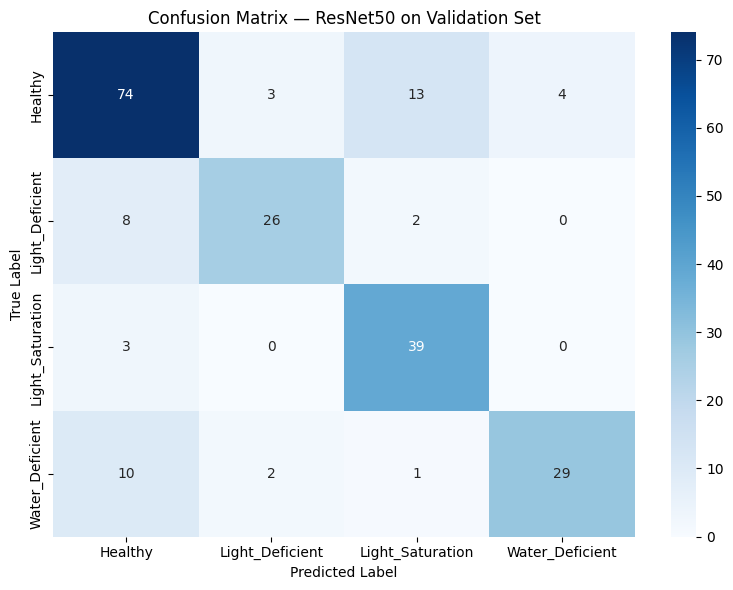

In [35]:
class_names = list(idx_to_class.values())

# Validation set
resnet50_val_results   = evaluate_model(resnet50, val_loader,   "ResNet50", "Validation Set")
plot_confusion_matrix(resnet50_val_results, class_names)

#### MobileNetV2


MobileNetV2 — Validation Set
Accuracy  : 0.6729
F1 Score  : 0.6621
Precision : 0.6885
Recall    : 0.6729

Full Classification Report:
                  precision    recall  f1-score   support

         Healthy       0.70      0.77      0.73        94
 Light_Deficient       0.84      0.58      0.69        36
Light_Saturation       0.57      0.86      0.69        42
 Water_Deficient       0.65      0.36      0.46        42

        accuracy                           0.67       214
       macro avg       0.69      0.64      0.64       214
    weighted avg       0.69      0.67      0.66       214



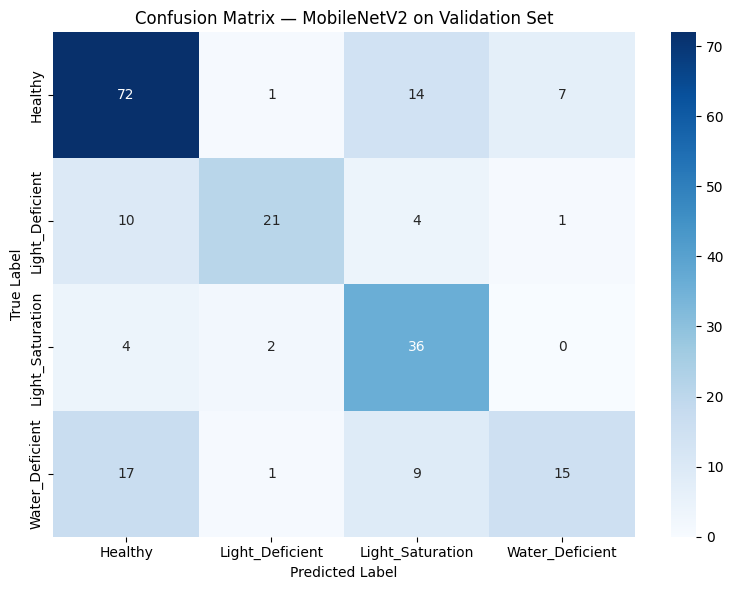

In [36]:
# Validation set
mobilenet_val_results   = evaluate_model(mobilenetv2, val_loader,   "MobileNetV2", "Validation Set")
plot_confusion_matrix(mobilenet_val_results, class_names)

#### Side-by-side

In [37]:
import pandas as pd

# Gather all results into a comparison table
comparison_data = [
    resnet50_val_results,
    mobilenet_val_results,
]

comparison_df = pd.DataFrame([
    {
        'Model'    : r['model_name'],
        'Accuracy' : f"{r['accuracy']:.4f}",
        'F1 Score' : f"{r['f1']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall'   : f"{r['recall']:.4f}",
    }
    for r in comparison_data
])

print(comparison_df.to_string(index=False))

      Model Accuracy F1 Score Precision Recall
   ResNet50   0.7850   0.7841    0.7949 0.7850
MobileNetV2   0.6729   0.6621    0.6885 0.6729


Visual Comparison

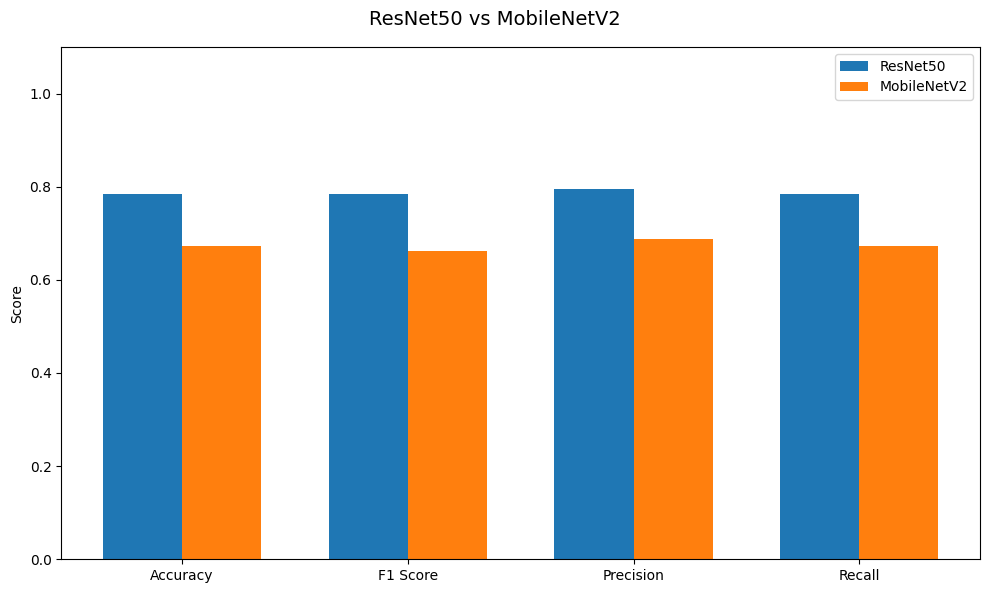

In [38]:
metrics   = ['accuracy', 'f1', 'precision', 'recall']
labels    = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
x         = np.arange(len(labels))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("ResNet50 vs MobileNetV2", fontsize=14)

resnet50_scores  = [resnet50_val_results[m]  for m in metrics]
mobilenet_scores = [mobilenet_val_results[m] for m in metrics]

ax.bar(x - bar_width/2, resnet50_scores,  bar_width, label='ResNet50')
ax.bar(x + bar_width/2, mobilenet_scores, bar_width, label='MobileNetV2')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.legend()

plt.tight_layout()

##### Save MobileNetV2 Model To Disk  

In [ ]:
mobilenetv2_cpu = mobilenetv2.cpu()
torch.save(mobilenetv2_cpu.state_dict(), 'I:/Capstone/Model/mobilenetv2_trained_cpu.pth')
print("MobileNetV2 saved successfully")
mobilenetv2 = mobilenetv2.to(device)

Model saved successfully


##### Save ResNet50 Model To Disk

In [41]:
torch.save(resnet50.state_dict(), 'I:/Capstone/Model/resnet50_trained.pth')
print("ResNet50 saved successfully")

ResNet50 saved successfully


In [42]:
# Check how many images of each class are in your training set
from collections import Counter

train_labels = [full_dataset.imgs[i][1] for i in train_data.indices]
label_counts = Counter(train_labels)

print("Training set class distribution:")
for label, count in sorted(label_counts.items()):
    print(f"  {idx_to_class[label]}: {count} images")

Training set class distribution:
  Healthy: 374 images
  Light_Deficient: 146 images
  Light_Saturation: 166 images
  Water_Deficient: 166 images


In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = list(idx_to_class.values())
cm = confusion_matrix(
    resnet50_val_results['labels'],
    resnet50_val_results['preds']
)

print("Confusion matrix row for Water Deficient:")
wd_idx = full_dataset.class_to_idx['Water_Deficient']
for i, name in enumerate(class_names):
    print(f"  Predicted as {name}: {cm[wd_idx][i]}")

Confusion matrix row for Water Deficient:
  Predicted as Healthy: 10
  Predicted as Light_Deficient: 2
  Predicted as Light_Saturation: 1
  Predicted as Water_Deficient: 29
